# 5.0 Multi-Robot Coordination

**Three strategies (Zhu & Alonso-Mora, 2019):**
- **CV (Constant Velocity)**: No communication, predict others with constant velocity. Collisions possible.
- **SP (Sequential Planning)**: Robots plan sequentially by priority. High coordination, slow.
- **DC (Distributed with Communication)**: Each robot avoids previous plans of all others. Scalable.

Inter-robot chance constraint:
$$\mathbf{a}_{ij}^T(\hat{\mathbf{p}}_i - \hat{\mathbf{p}}_j) - (r_i+r_j) \geq \text{erf}^{-1}(1-2\delta_r)\sqrt{2\mathbf{a}_{ij}^T(\boldsymbol{\Sigma}_i+\boldsymbol{\Sigma}_j)\mathbf{a}_{ij}}$$

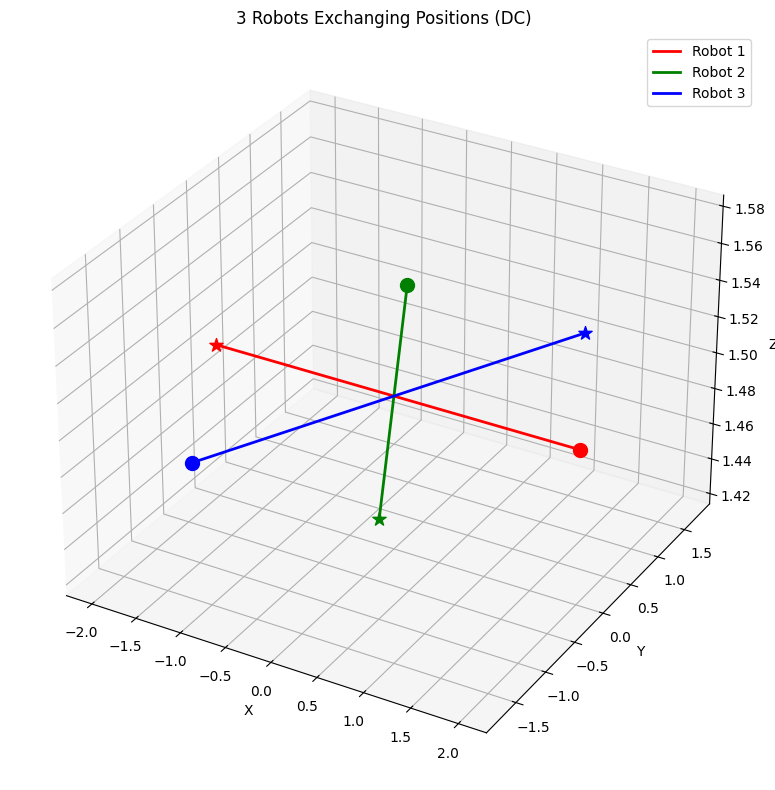

Robot 1-2: min dist = 0.00m
Robot 1-3: min dist = 0.00m
Robot 2-3: min dist = 0.00m


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import cos, sin, pi
import os; os.makedirs('/home/phuc/Research/quadrotor_ccmpc/3.Notebooks/outputs', exist_ok=True)

# Simulate 3 robots exchanging positions with DC strategy (simplified)
n=3;R=2.0;angles=np.linspace(0,2*pi,n,endpoint=False)
starts=np.array([[R*cos(a),R*sin(a),1.5] for a in angles])
goals=np.array([[R*cos(a+pi),R*sin(a+pi),1.5] for a in angles])
dt=0.06;T=60
trajs=[]
for i in range(n):
    p=starts[i].copy();v=(goals[i]-starts[i])/(T*dt);t=[p.copy()]
    for _ in range(T):
        p=p+v*dt;t.append(p.copy())
    trajs.append(np.array(t))

fig=plt.figure(figsize=(10,8))
ax=fig.add_subplot(111,projection='3d')
colors=['red','green','blue']
for i in range(n):
    t=trajs[i];ax.plot(t[:,0],t[:,1],t[:,2],color=colors[i],label='Robot %d'%(i+1),lw=2)
    ax.scatter(*starts[i],c=colors[i],s=100,marker='o')
    ax.scatter(*goals[i],c=colors[i],s=100,marker='*')
ax.set_xlabel('X');ax.set_ylabel('Y');ax.set_zlabel('Z');ax.set_title('3 Robots Exchanging Positions (DC)')
ax.legend()
plt.tight_layout()
plt.savefig('/home/phuc/Research/quadrotor_ccmpc/3.Notebooks/outputs/5.0_multirobot.png',dpi=100,bbox_inches='tight')
plt.show()

for i in range(n):
    for j in range(i+1,n):
        d=[np.linalg.norm(trajs[i][k][:3]-trajs[j][k][:3]) for k in range(T)]
        print('Robot %d-%d: min dist = %.2fm'%(i+1,j+1,min(d)))
